In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import numpy as np
import matplotlib.pyplot as plt
# Function to apply convolution manually using NumPy (no padding)
def conv2d_nopadding(image, kernel):
    # Get dimensions
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # Output dimensions (valid convolution)
    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1

    # Initialize output
    output = np.zeros((output_height, output_width))

    # Convolution operation
    for i in range(output_height):
        for j in range(output_width):
            # Extract region
            region = image[i:i + kernel_height, j:j + kernel_width]

            # Element-wise multiplication and sum
            output[i, j] = np.sum(region * kernel)

    return output

In [7]:
from PIL import Image
img = Image.open("/content/drive/MyDrive/Lenna.png").convert("L")
img_array = np.array(img)
print(img_array)
print(img_array.shape)  # (height, width, channels)

[[162 162 162 ... 170 155 128]
 [162 162 162 ... 170 155 128]
 [162 162 162 ... 170 155 128]
 ...
 [ 43  43  50 ... 104 100  98]
 [ 44  44  55 ... 104 105 108]
 [ 44  44  55 ... 104 105 108]]
(512, 512)


In [8]:
kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])
result = conv2d_nopadding(img_array, kernel)
print(result)

[[   0.   -4.    0. ...    0.  -64. -168.]
 [   0.   -4.    0. ...    0.  -64. -168.]
 [   0.   -4.    0. ...    0.  -64. -168.]
 ...
 [   9.    5.   13. ...   29.    0.  -21.]
 [  29.   19.    9. ...   22.    3.  -14.]
 [  40.   25.    1. ...    4.   15.    6.]]


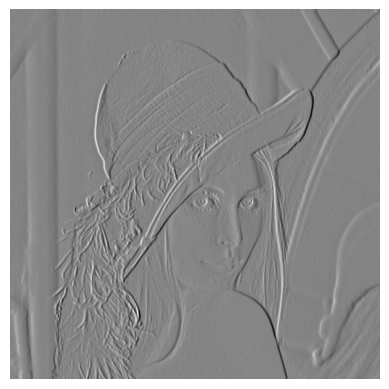

In [13]:
plt.imshow(result, cmap='gray')
plt.axis('off')
plt.show()